# Formula 1 — Exploratory Data Analysis
### Milestone 1 — COM-480

Overview of the dataset structure, data quality, and key insights across circuits, drivers, constructors, and race strategy.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path('data/')    # folder containing the CSV files
FIG_DIR  = Path('figures/') # folder where plots will be saved
FIG_DIR.mkdir(exist_ok=True)

def load(name):
    return pd.read_csv(DATA_DIR / f'{name}.csv')

circuits              = load('circuits')
constructor_results   = load('constructor_results')
constructor_standings = load('constructor_standings')
constructors          = load('constructors')
driver_standings      = load('driver_standings')
drivers               = load('drivers')
lap_times             = load('lap_times')
pit_stops             = load('pit_stops')
qualifying            = load('qualifying')
races                 = load('races')
results               = load('results')
seasons               = load('seasons')
sprint_results        = load('sprint_results')
status                = load('status')

print('Files loaded.')

Files loaded.


## 2. Dataset at a Glance

In [2]:
print(f"Seasons : {races.year.min()} – {races.year.max()}  ({races.year.nunique()} seasons)")
print(f"Races   : {len(races):,}")
print(f"Circuits: {len(circuits)}  across {circuits.country.nunique()} countries")
print(f"Drivers : {len(drivers)}")
print(f"Teams   : {len(constructors)}")
print()
print(f"Race results rows : {len(results):,}")
print(f"Lap times rows    : {len(lap_times):,}  (available from 1996)")
print(f"Pit stop rows     : {len(pit_stops):,}  (available from 2011)")

Seasons : 1950 – 2026  (77 seasons)
Races   : 1,171
Circuits: 78  across 35 countries
Drivers : 865
Teams   : 214

Race results rows : 27,282
Lap times rows    : 617,660  (available from 1996)
Pit stop rows     : 22,164  (available from 2011)


---
# Data Quality

## 3. Global Missing Value Report

We check both standard `NaN` nulls and the `\N` string sentinel used throughout this dataset.

In [3]:
all_dfs = {
    'circuits': circuits, 'constructors': constructors, 'drivers': drivers,
    'races': races, 'results': results, 'status': status,
    'lap_times': lap_times, 'pit_stops': pit_stops, 'qualifying': qualifying,
    'seasons': seasons, 'sprint_results': sprint_results,
    'constructor_results': constructor_results,
    'constructor_standings': constructor_standings,
    'driver_standings': driver_standings
}

quality_report = []
for name, df in all_dfs.items():
    total_cells   = len(df) * len(df.columns)
    nan_count     = df.isnull().sum().sum()
    slash_n_count = (df == r'\N').sum().sum()
    total_missing = nan_count + slash_n_count
    quality_report.append({
        'Dataset':          name,
        'Rows':             len(df),
        'NaN':              nan_count,
        r'\N sentinel':     slash_n_count,
        'Total Missing':    total_missing,
        'Quality Score (%)': round((1 - total_missing / total_cells) * 100, 1)
    })

quality_df = pd.DataFrame(quality_report).sort_values('Quality Score (%)')
print(quality_df.to_string(index=False))

              Dataset   Rows  NaN  \N sentinel  Total Missing  Quality Score (%)
                races   1171    0        11477          11477               45.5
              results  27282    0       123850         123850               74.8
              drivers    865    0         1559           1559               80.0
  constructor_results  12887    0        12870          12870               80.0
           qualifying  11014    0        12075          12075               87.8
       sprint_results    502    0          473            473               94.5
             circuits     78    0            0              0              100.0
         constructors    214    0            0              0              100.0
               status    140    0            0              0              100.0
            lap_times 617660    0            0              0              100.0
            pit_stops  22164    0            6              6              100.0
              seasons     77

## 3b. Clean: Replace `\N` Sentinels and Cast Columns

Now that the quality report is done, we replace `\N` with proper `NaN` and cast numeric columns.

In [4]:
# Replace \N sentinel across all dataframes
for name, df in all_dfs.items():
    df.replace(r'\N', np.nan, inplace=True)

# Cast the columns we'll use
results['position']       = pd.to_numeric(results['position'],       errors='coerce')
results['grid']           = pd.to_numeric(results['grid'],           errors='coerce')
pit_stops['milliseconds'] = pd.to_numeric(pit_stops['milliseconds'], errors='coerce')
pit_stops['duration']     = pd.to_numeric(pit_stops['duration'],     errors='coerce')
lap_times['milliseconds'] = pd.to_numeric(lap_times['milliseconds'], errors='coerce')

print('Data cleaned and ready.')

Data cleaned and ready.


## 4. Historical Completeness Check

Not all data types are available for the full history — lap times start in 1996, pit stops in 2011.

Lap Times                : 1996 – 2026
Pit Stops                : 1994 – 2026
Qualifying               : 1994 – 2026
Results (Fastest Lap)    : 1950 – 2026


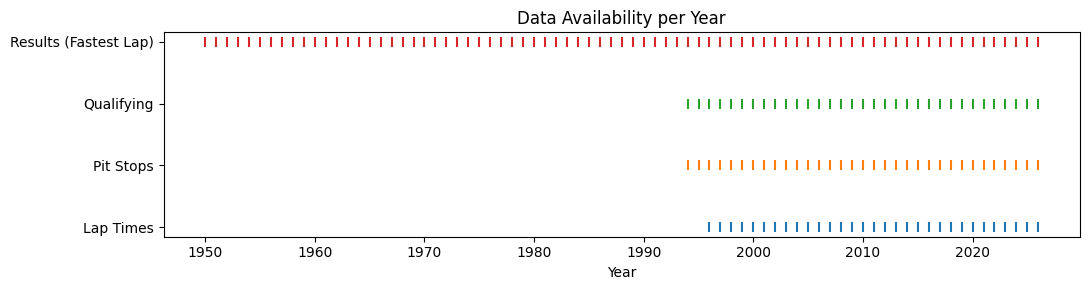

In [5]:
check_times = {
    'Lap Times':           lap_times.merge(races[['raceId', 'year']], on='raceId'),
    'Pit Stops':           pit_stops.merge(races[['raceId', 'year']], on='raceId'),
    'Qualifying':          qualifying.merge(races[['raceId', 'year']], on='raceId'),
    'Results (Fastest Lap)': results.merge(races[['raceId', 'year']], on='raceId'),
}

for name, df in check_times.items():
    print(f"{name:25s}: {int(df['year'].min())} – {int(df['year'].max())}")

plt.figure(figsize=(11, 3))
for name, df in check_times.items():
    plt.scatter(df['year'].unique(), [name] * len(df['year'].unique()), marker='|', s=60)
plt.title('Data Availability per Year')
plt.xlabel('Year')
plt.tight_layout()
plt.savefig(FIG_DIR / 'data_availability.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Duplicate Detection

In [6]:
lap_dupes = lap_times.duplicated(subset=['raceId', 'driverId', 'lap']).sum()
pit_dupes = pit_stops.duplicated(subset=['raceId', 'driverId', 'stop']).sum()

print(f"Duplicate lap records : {lap_dupes}")
print(f"Duplicate pit records : {pit_dupes}")

Duplicate lap records : 0
Duplicate pit records : 0


---
# Exploratory Analysis

## 6. How the Calendar Has Grown

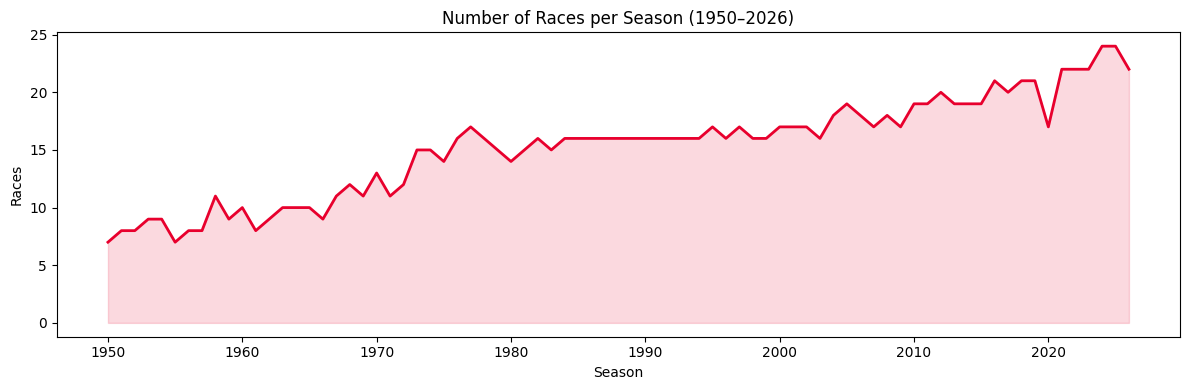

Smallest calendar : 7 races (1950)
Largest calendar  : 24 races (2024)


In [7]:
races_per_year = races.groupby('year').size()

plt.figure(figsize=(12, 4))
plt.plot(races_per_year.index, races_per_year.values, color='#E8002D', linewidth=2)
plt.fill_between(races_per_year.index, races_per_year.values, alpha=0.15, color='#E8002D')
plt.title('Number of Races per Season (1950–2026)')
plt.xlabel('Season')
plt.ylabel('Races')
plt.tight_layout()
plt.savefig(FIG_DIR / 'races_per_season.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Smallest calendar : {races_per_year.min()} races ({races_per_year.idxmin()})")
print(f"Largest calendar  : {races_per_year.max()} races ({races_per_year.idxmax()})")

## 7. Focus: The 2023 Season

A quick snapshot of a recent, complete season.

2023 had 22 races.


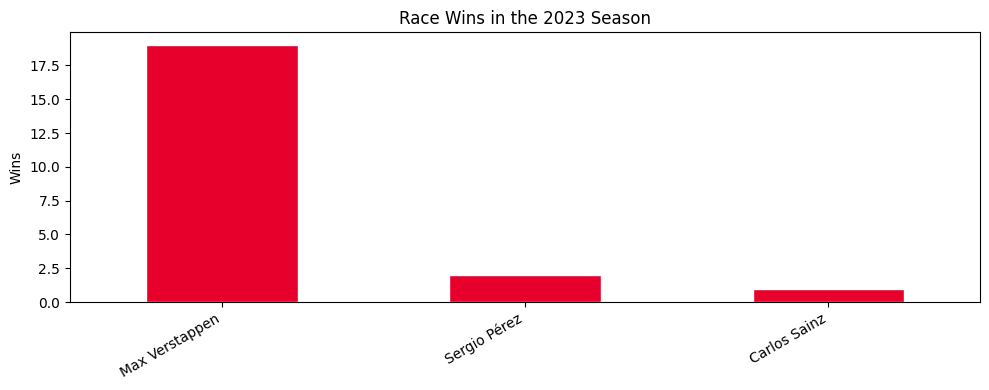

In [8]:
races_2023   = races[races.year == 2023]
ids_2023     = races_2023.raceId.tolist()
results_2023 = results[results.raceId.isin(ids_2023)]

print(f"2023 had {len(races_2023)} races.")

wins_2023 = (
    results_2023[results_2023.position == 1]
    .groupby('driverId').size()
    .reset_index(name='wins')
    .merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
    .assign(name=lambda df: df.forename + ' ' + df.surname)
    .sort_values('wins', ascending=False)
)

wins_2023[['name', 'wins']].plot(
    kind='bar', x='name', y='wins',
    figsize=(10, 4), legend=False, color='#E8002D', edgecolor='white'
)
plt.title('Race Wins in the 2023 Season')
plt.xlabel('')
plt.ylabel('Wins')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'wins_2023.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Focus: Lewis Hamilton's Career

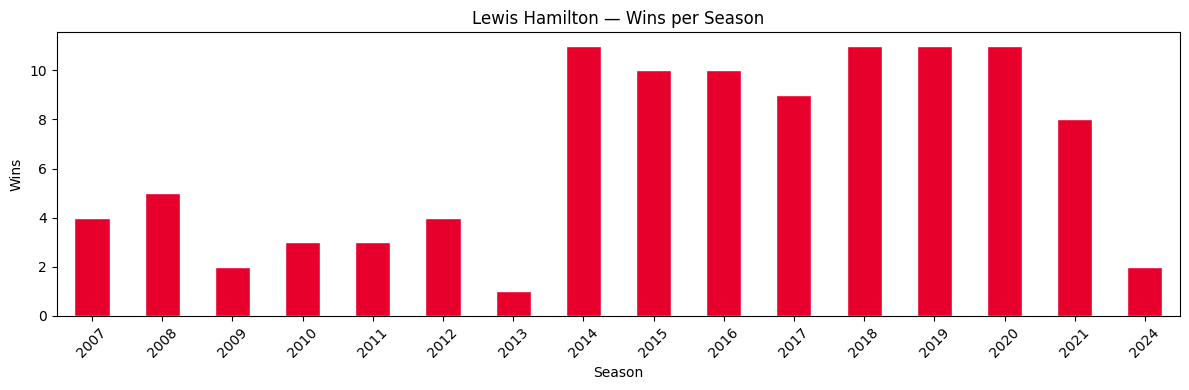

Career races : 382
Career wins  : 105
Pole starts  : 104
Win rate     : 27.5%


In [9]:
ham_id = drivers[drivers.surname == 'Hamilton'].iloc[0].driverId

ham_results = (
    results[results.driverId == ham_id]
    .merge(races[['raceId', 'year']], on='raceId')
)

ham_wins_by_year = ham_results[ham_results.position == 1].groupby('year').size()

ham_wins_by_year.plot(kind='bar', figsize=(12, 4), color='#E8002D', edgecolor='white')
plt.title('Lewis Hamilton — Wins per Season')
plt.xlabel('Season')
plt.ylabel('Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / 'hamilton_wins.png', dpi=150, bbox_inches='tight')
plt.show()

total_races = len(ham_results)
total_wins  = int((ham_results.position == 1).sum())
total_poles = int((ham_results.grid == 1).sum())
print(f"Career races : {total_races}")
print(f"Career wins  : {total_wins}")
print(f"Pole starts  : {total_poles}")
print(f"Win rate     : {total_wins / total_races * 100:.1f}%")

## 9. Focus: Red Bull's Dominance

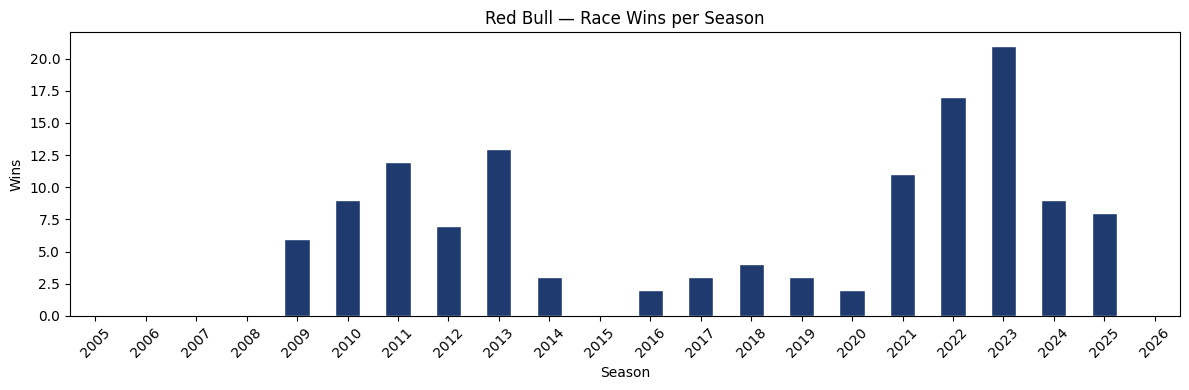

Red Bull total wins : 130
Best season         : 2023 with 21 wins


In [10]:
rb_id = constructors[constructors.name == 'Red Bull'].iloc[0].constructorId

rb_results = (
    results[results.constructorId == rb_id]
    .merge(races[['raceId', 'year']], on='raceId')
)

rb_wins = (
    rb_results[rb_results.position == 1]
    .groupby('year').size()
    .reindex(range(rb_results.year.min(), rb_results.year.max() + 1), fill_value=0)
)

rb_wins.plot(kind='bar', figsize=(12, 4), color='#1E3A6E', edgecolor='white')
plt.title('Red Bull — Race Wins per Season')
plt.xlabel('Season')
plt.ylabel('Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / 'redbull_wins.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Red Bull total wins : {int((rb_results.position == 1).sum())}")
print(f"Best season         : {rb_wins.idxmax()} with {rb_wins.max()} wins")

## 10. DNF Rate — Has Racing Gotten Safer?

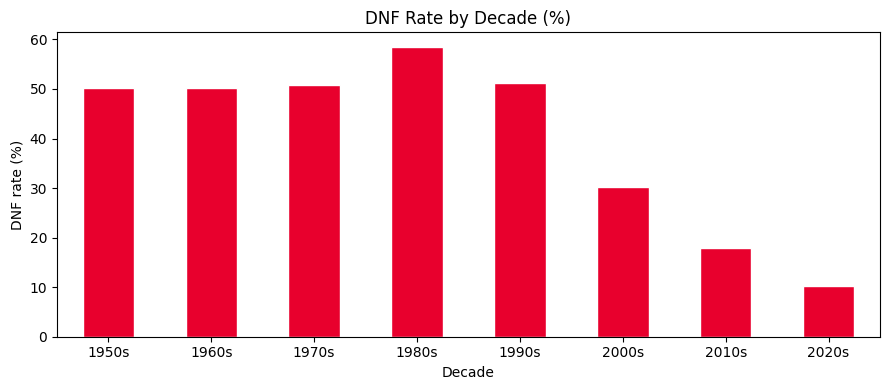

decade
1950    50.2
1960    50.1
1970    50.8
1980    58.5
1990    51.2
2000    30.2
2010    17.9
2020    10.2


In [11]:
results_year = results.merge(races[['raceId', 'year']], on='raceId')
results_year['decade'] = (results_year['year'] // 10) * 10
results_year['dnf']    = results_year['position'].isna().astype(int)

dnf_by_decade = results_year.groupby('decade')['dnf'].mean().mul(100).round(1)

dnf_by_decade.plot(kind='bar', figsize=(9, 4), color='#E8002D', edgecolor='white')
plt.title('DNF Rate by Decade (%)')
plt.xlabel('Decade')
plt.ylabel('DNF rate (%)')
plt.xticks(range(len(dnf_by_decade)), [f"{int(d)}s" for d in dnf_by_decade.index], rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'dnf_rate_by_decade.png', dpi=150, bbox_inches='tight')
plt.show()

print(dnf_by_decade.to_string())

---
# Pit Stop Analysis

## 11. Pit Stop Durations by Grand Prix (2023 Season)

Variation in pit stop durations across different circuits — some circuits have tighter pit lanes and trickier stops.

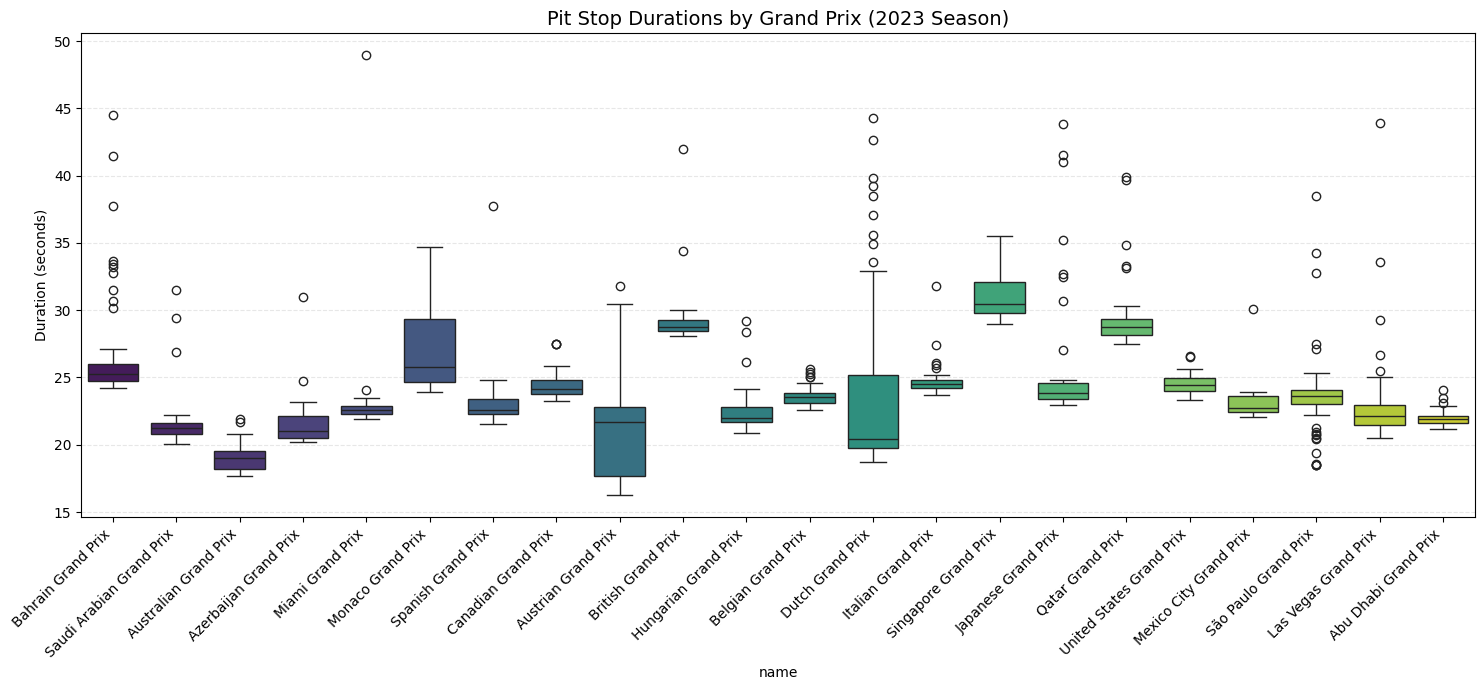

In [12]:
pit_summary = pit_stops.merge(races[['raceId', 'name', 'year']], on='raceId')
pit_2023 = pit_summary[pit_summary['year'] == 2023].copy()
pit_2023['seconds'] = pit_2023['milliseconds'] / 1000
pit_2023 = pit_2023[pit_2023['seconds'] < 50]  # remove repair outliers

plt.figure(figsize=(15, 7))
sns.boxplot(data=pit_2023, x='name', y='seconds', hue='name', palette='viridis', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Pit Stop Durations by Grand Prix (2023 Season)', fontsize=14)
plt.ylabel('Duration (seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'pitstops_by_gp_2023.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Pit Stop Duration vs. Final Position (2023)

Is there a relationship between faster pit stops and better race results?

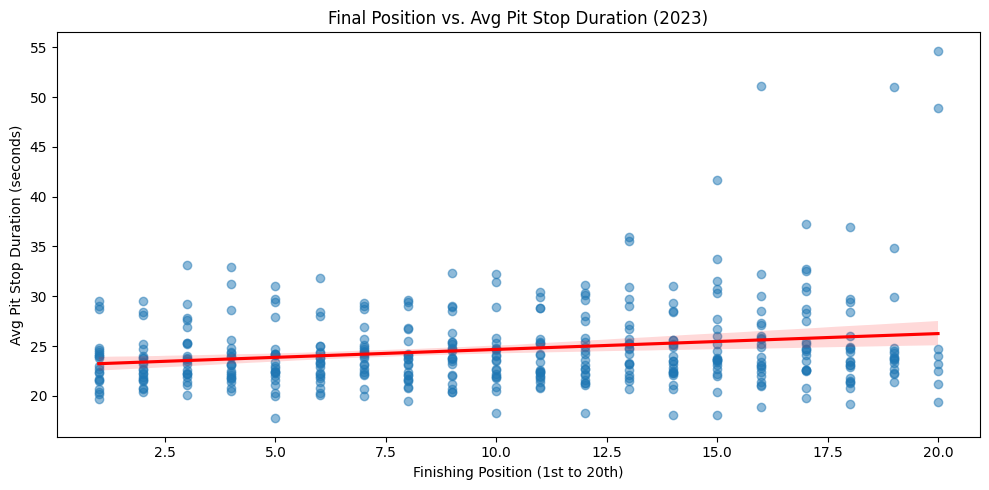

In [13]:
driver_pit_avg = (
    pit_stops.groupby(['raceId', 'driverId'])['duration']
    .mean()
    .reset_index(name='avg_duration')
)

pit_results = (
    driver_pit_avg
    .merge(results[['raceId', 'driverId', 'positionOrder']], on=['raceId', 'driverId'])
    .merge(races[['raceId', 'year']], on='raceId')
)
pit_results_2023 = pit_results[pit_results['year'] == 2023]

plt.figure(figsize=(10, 5))
sns.regplot(
    data=pit_results_2023, x='positionOrder', y='avg_duration',
    scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}
)
plt.title('Final Position vs. Avg Pit Stop Duration (2023)')
plt.xlabel('Finishing Position (1st to 20th)')
plt.ylabel('Avg Pit Stop Duration (seconds)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'pitstop_vs_position_2023.png', dpi=150, bbox_inches='tight')
plt.show()

Drivers finishing in the top 5 tend to have shorter pit durations than those finishing at the back — a reminder that in F1 it's not just about the driver but the whole team.

## 13. Evolution of Pit Stop Speed (2011–present)

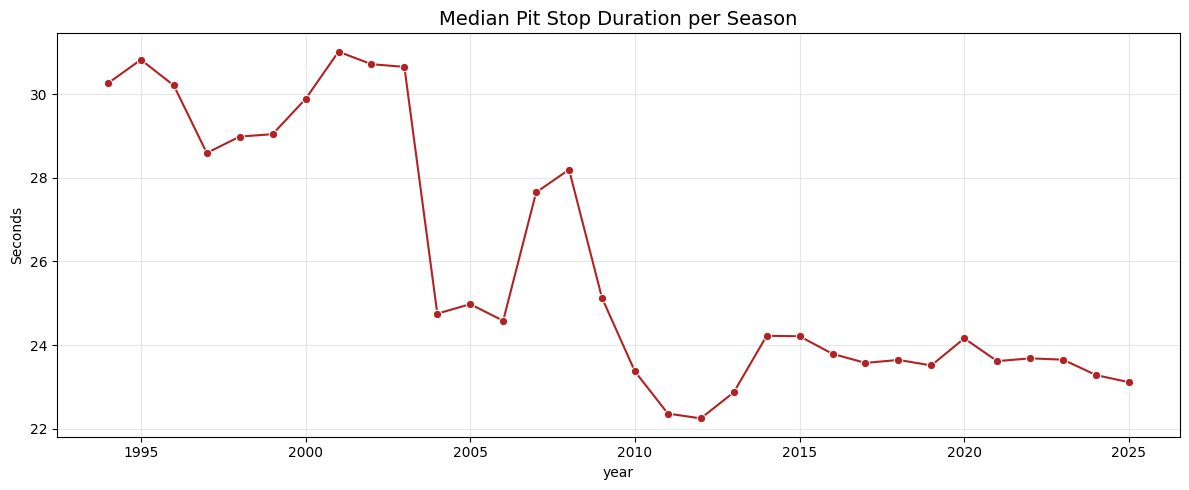

In [14]:
pit_history = pit_stops.merge(races[['raceId', 'year']], on='raceId')
pit_history = pit_history[pit_history['duration'] < 50]  # exclude repairs

yearly_pit = pit_history.groupby('year')['duration'].median().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly_pit, x='year', y='duration', marker='o', color='firebrick')
plt.title('Median Pit Stop Duration per Season', fontsize=14)
plt.ylabel('Seconds')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'pitstop_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Evolution of Lap Times Across Technical Eras

Using Monza (Italian GP) as a consistent reference circuit.

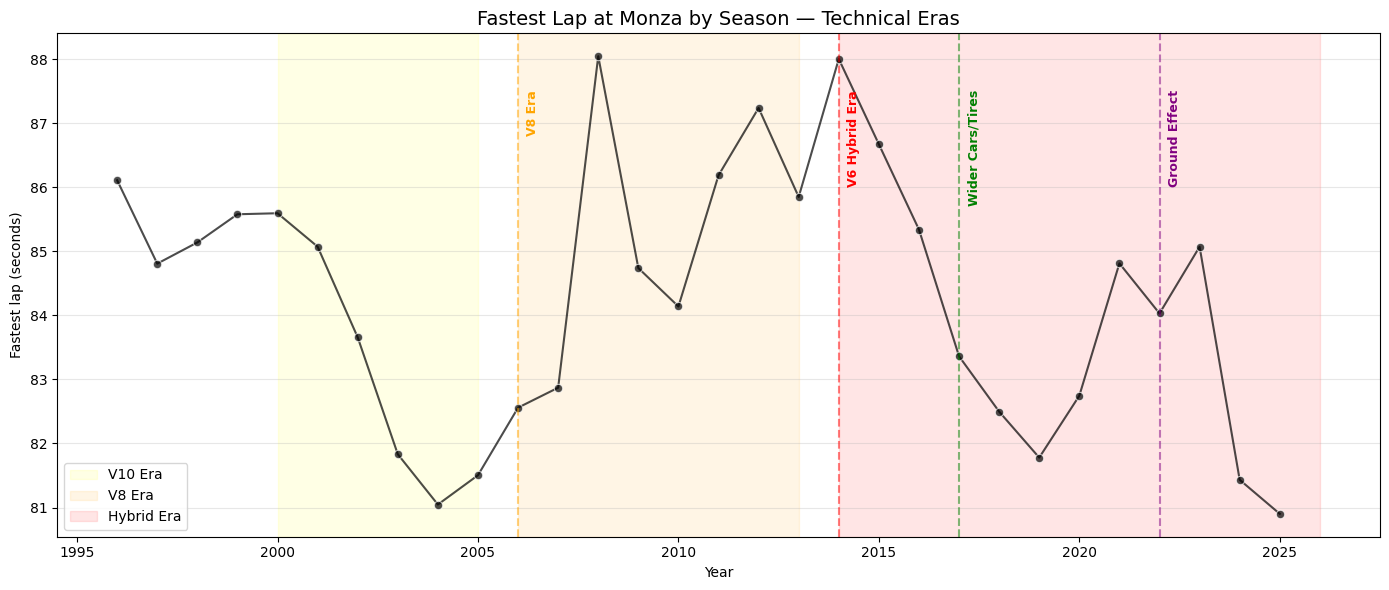

In [15]:
monza_id    = circuits[circuits.name == 'Autodromo Nazionale di Monza'].iloc[0].circuitId
monza_races = races[races.circuitId == monza_id][['raceId', 'year']]
monza_laps  = lap_times.merge(monza_races, on='raceId')

yearly_best = (
    monza_laps.groupby('year')['milliseconds']
    .min()
    .reset_index()
    .rename(columns={'milliseconds': 'fastest_ms'})
)
yearly_best['fastest_sec'] = yearly_best['fastest_ms'] / 1000

rule_changes = [
    {'year': 2006, 'label': 'V8 Era',          'color': 'orange'},
    {'year': 2014, 'label': 'V6 Hybrid Era',   'color': 'red'},
    {'year': 2017, 'label': 'Wider Cars/Tires','color': 'green'},
    {'year': 2022, 'label': 'Ground Effect',   'color': 'purple'},
]

plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_best, x='year', y='fastest_sec', marker='o', color='black', alpha=0.7)

for change in rule_changes:
    plt.axvline(x=change['year'], color=change['color'], linestyle='--', alpha=0.5)
    plt.text(change['year'] + 0.2, plt.ylim()[1] * 0.99, change['label'],
             rotation=90, va='top', fontsize=9, color=change['color'], fontweight='bold')

plt.axvspan(2000, 2005, color='yellow', alpha=0.1, label='V10 Era')
plt.axvspan(2006, 2013, color='orange', alpha=0.1, label='V8 Era')
plt.axvspan(2014, 2026, color='red',    alpha=0.1, label='Hybrid Era')

plt.title('Fastest Lap at Monza by Season — Technical Eras', fontsize=14)
plt.ylabel('Fastest lap (seconds)')
plt.xlabel('Year')
plt.grid(True, axis='y', alpha=0.3)
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'monza_lap_times.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

- The dataset is **clean and well-structured**; `\N` string sentinels are used instead of true nulls and must be replaced before analysis. Most missing values in `results` are structurally expected (DNFs have no finish time).
- **Coverage gaps**: lap times start in 1996, pit stops in 2011, qualifying in 1994 — this scopes some of our planned visualisations.
- **No duplicates** found in lap or pit stop records.
- The **2023 season** illustrates extreme Verstappen / Red Bull dominance — a compelling story to visualise.
- **DNF rates** fell from ~50% in the 1950s to ~10% today, reflecting both mechanical and safety improvements.
- **Pit stops** show a clear link between team performance and race result, and average durations have hovered around 23–25 seconds since 2011.
- **Lap times at Monza** capture the impact of major regulation changes across technical eras.